# PRACTICAL 5

In [1]:
# (A)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns = iris.feature_names)

df["species"] = iris.target
df["species"] = df["species"].map({0:'setosa' , 1:'versicolor', 2:'virginica'})

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [2]:
df.head(150)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
# (B)

print("Missing Values: \n", df.isnull().sum())


Missing Values: 
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


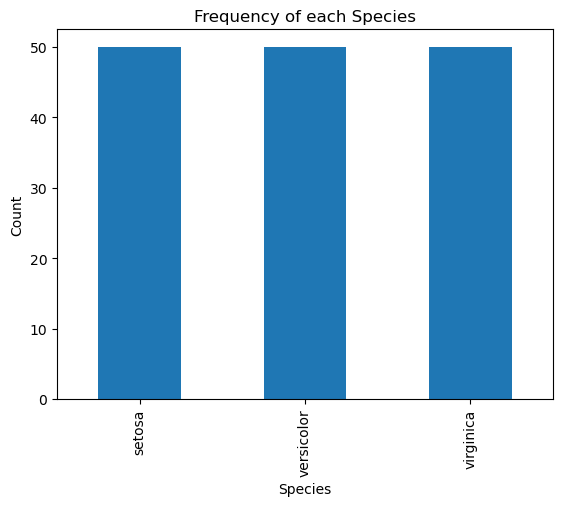

In [4]:
# (C)

df['species'].value_counts().plot(kind='bar')
plt.title("Frequency of each Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

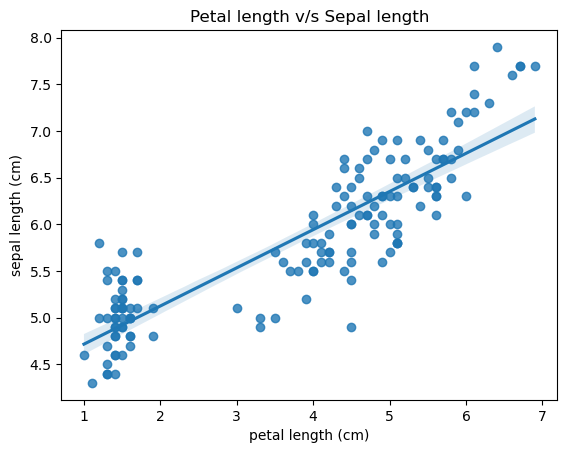

In [5]:
# (D)

sns.regplot(x='petal length (cm)', y='sepal length (cm)', data=df)
plt.title("Petal length v/s Sepal length")
plt.show()

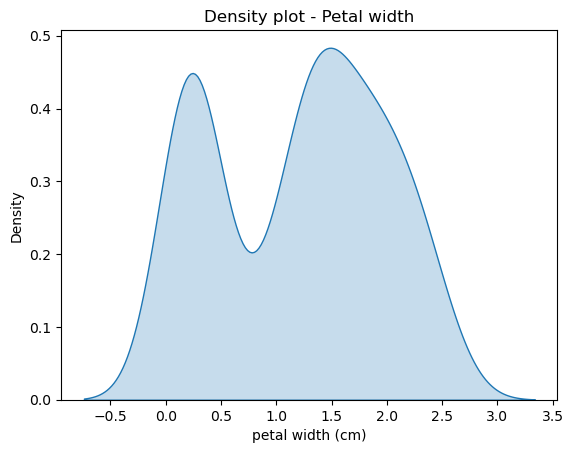

In [6]:
# (E)

sns.kdeplot(df['petal width (cm)'], fill=True)
plt.title("Density plot - Petal width")
plt.show()

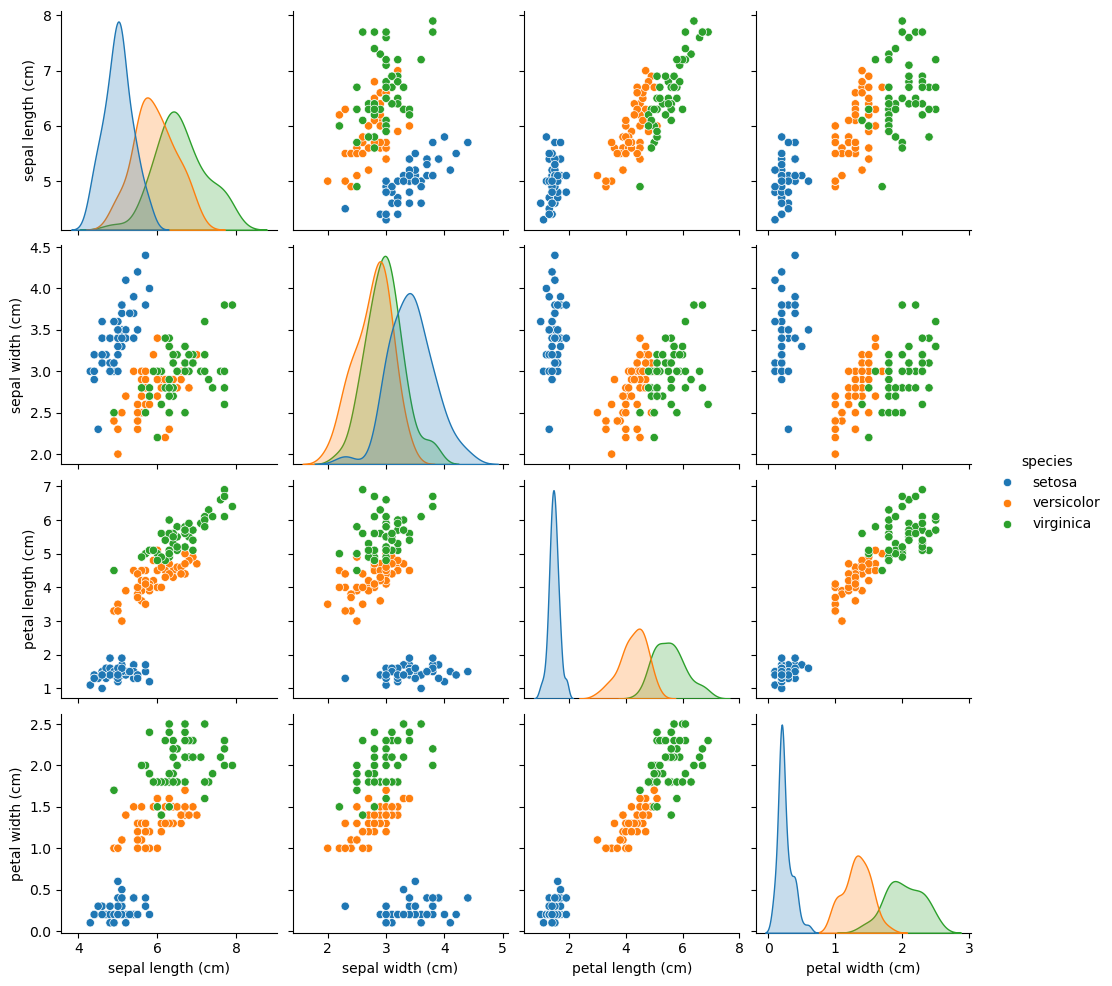

In [7]:
# (F)

sns.pairplot(df, hue='species')
plt.show()

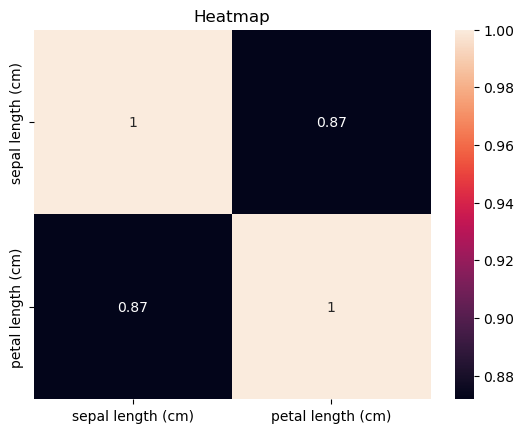

In [8]:
# (G)

subset = df[['sepal length (cm)', 'petal length (cm)']]
sns.heatmap(subset.corr(), annot = True)
plt.title("Heatmap")
plt.show()

In [9]:
# (H)

print("Mean:\n" , df.mean(numeric_only=True))
print("Median:\n" , df.median(numeric_only=True))
print("Mode:\n" , df.mode(numeric_only=True).iloc[0])
print("Standard Deviation:\n" , df.std(numeric_only=True))
print("Standard Error:\n" , df.sem(numeric_only=True))

from scipy import stats
for col in df.select_dtypes(include=np.number).columns:
    data = df[col]
    ci = stats.t.interval(0.95,len(data)-1, loc =np.mean(data),scale=stats.sem(data))
    print(f"\n 95% Confidence interval for {col}:{ci}")

Mean:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64
Median:
 sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64
Mode:
 sepal length (cm)    5.0
sepal width (cm)     3.0
petal length (cm)    1.4
petal width (cm)     0.2
Name: 0, dtype: float64
Standard Deviation:
 sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64
Standard Error:
 sepal length (cm)    0.067611
sepal width (cm)     0.035588
petal length (cm)    0.144136
petal width (cm)     0.062236
dtype: float64

 95% Confidence interval for sepal length (cm):(np.float64(5.709732481507366), np.float64(5.976934185159301))

 95% Confidence interval for sepal width (cm):(np.float64(2.9870103180785432), np.float64(3.127656348588124))

 95% Confidence interval for petal length (cm):(np.float64(3.4731853

Correlation Matrix :
                    sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


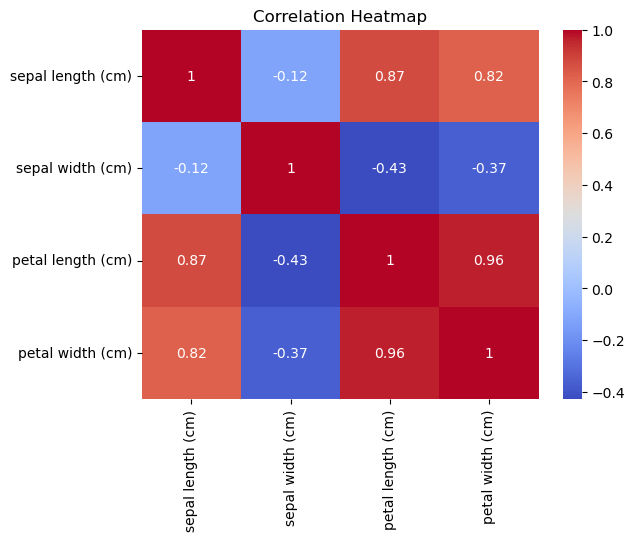

In [10]:
# (I)

corr = df.corr(numeric_only = True)
print("Correlation Matrix :\n", corr)
sns.heatmap(corr, annot = True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()